# Stochastic Gradient Descent

The main problem with Batch Gradient Descent is the fact that it uses the whole training set to compute the gradients at every step, which makes it very slow when the training set is large.

At opposite extreme, *Stochastic Gradient Descent* picks a random instance in the training set at every step and computes the gradients based only on that single instance. 

On the other hand, due to its stochastic (i.e., random) nature, this algorithm is much less regular than Batch Gradient Descent: instead of gently decreasing until it reaches the minimum, the cost function will be bounch up and down, decreasing only on average. Over time it will end up very close to the minimum, but once it gets there it will continue to bounce around, never settling down. So once the algorithm stops, the final parameter values are good, but not optimal

---

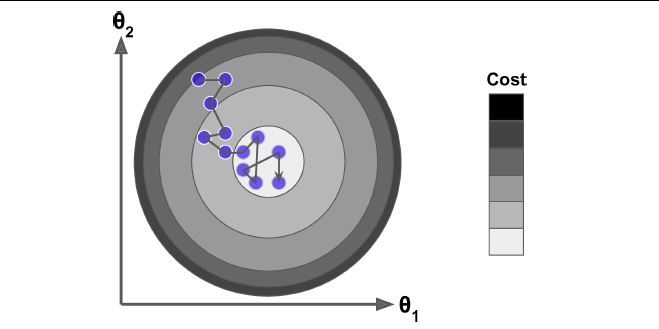

When the cost function is very irregualr, this can actually help the algorithm jump out of the local minima, so Stochastic Gradient has a better chance of finding the global minimum than Batch Gradient Descent does

Therefore, randomness is good to escape from local optima, but bad because it means that the algoritm can never settle at the minimum.

---

In [4]:
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [5]:
X, y = load_diabetes(return_X_y = True)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (442, 10)
y shape: (442,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

print(f'X train shape: {X_train.shape}')
print(f'y train shape: {y_train.shape}')

print(f'X test shape: {X_test.shape}')
print(f'y test shape: {y_test.shape}')

X train shape: (353, 10)
y train shape: (353,)
X test shape: (89, 10)
y test shape: (89,)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [8]:
r2_score(y_test, y_pred)

0.4399338661568969

In [9]:
model.intercept_

np.float64(151.88331005254167)

In [10]:
model.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

### Stocahstic Gradient Descent From Scracth

In [11]:
class SGDRegressor:
    def __init__(self, alpha = 0.01, epochs = 100):
        self.intercept_ = None
        self.coef_ = None
        self.alpha = alpha
        self.epochs = epochs

    def fit(self, X_train, y_train):
        # Step 1: Initialize with random number
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        intercept = []
        coefficients = []
       

        # Step 2: Apply Gradient Descent
        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0, X_train.shape[0])

                y_pred = np.dot(X_train[idx], self.coef_) + self.intercept_
                error = y_pred - y_train[idx]

                gradient_of_intercept = 2*error
                self.intercept_ = self.intercept_ - self.alpha * gradient_of_intercept

                gradient_of_coefficients = 2 * np.dot(error, X_train[idx])
                self.coef_ = self.coef_ - self.alpha * gradient_of_coefficients

                intercept.append(self.intercept_)
                coefficients.append(self.coef_.copy())



                
                 
        # print("Intercept history:", intercept)
        # print("\nCoefficient history:", coefficients)

            
        print(self.intercept_)
        print()
        print(self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_
            

In [12]:
model = SGDRegressor(alpha = 0.01, epochs = 100)
model.fit(X_train, y_train)

149.27746406454975

[  32.45704404 -130.83289648  445.73731223  305.1683118   -24.44417023
  -97.29562013 -188.7363526   112.64080197  413.37202983  111.43264085]


In [13]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.4491142695927205

|Learning Schedule|
|:---------------:|
|The solution of the dilemma due to the randomness is to gradually reduce the learning rate. The steps start out large (which helps make quick progress and escape local minima), then get smaller and smaller, allowing the algorithm to settle at the global minimum. This process is akin to *simulated annealing*, an algorithm inspired from the process in metallurgy of annealing. The function that determines the learning rate at each iteration is called *the learning schedule*. If the learning rate is reduced too quickly, you may get stuck in a local minimum, or even end up frozen halfway to the minumum. If the learning rate is reduced too slowly, you may jump around the minimum for a long time and end up with a suboptimal solution if you halt training too early|

In [14]:
class SGDRegressor:
    def __init__(self, alpha = 0.01, epochs = 100, learning_rate = 'invscaling', power_t = 0.25):
        self.intercept_ = None
        self.coef_ = None
        self.initial_alpha = alpha
        self.alpha = alpha
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.power_t = power_t
        self.alpha_history_ = []

    def fit(self, X_train, y_train):
        # Step 1: Initialize with random number
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        intercept = []
        coefficients = []
        self.alpha_history_ = []

        step = 1
       

        # Step 2: Apply Gradient Descent
        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0, X_train.shape[0])

                if self.learning_rate == 'invscaling':
                    self.alpha = self.initial_alpha / (step**self.power_t)

                self.alpha_history_.append(self.alpha)

                y_pred = np.dot(X_train[idx], self.coef_) + self.intercept_
                error = y_pred - y_train[idx]

                gradient_of_intercept = 2*error
                self.intercept_ = self.intercept_ - self.alpha * gradient_of_intercept

                gradient_of_coefficients = 2 * np.dot(error, X_train[idx])
                self.coef_ = self.coef_ - self.alpha * gradient_of_coefficients

                intercept.append(self.intercept_)
                coefficients.append(self.coef_.copy())


                step += 1
                
                 
        # print("Intercept history:", intercept)
        # print("\nCoefficient history:", coefficients)

            
        print(self.intercept_)
        print()
        print(self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_
            

In [15]:
# Assuming you already created a dummy dataset X_train, y_train
model = SGDRegressor(alpha=0.11, epochs=100)
model.fit(X_train, y_train)

# View specific milestones
print(f"Starting Alpha (Step 1): {model.alpha_history_[0]}")
print(f"Mid-way Alpha (Step {len(model.alpha_history_) // 2}): {model.alpha_history_[len(model.alpha_history_) // 2]}")
print(f"Final Alpha (Step {len(model.alpha_history_)}): {model.alpha_history_[-1]}")

152.2013072726418

[  25.75541192 -138.28892563  465.06805551  304.99741217  -22.27199598
  -96.85734253 -186.4344277   109.77181431  415.9970402   119.33807236]
Starting Alpha (Step 1): 0.11
Mid-way Alpha (Step 17650): 0.009543339115215429
Final Alpha (Step 35300): 0.00802507331710398


In [16]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.4523543589516763

### Stochastic Gradient Descent Using Scikit-learn

In [20]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(max_iter = 100, learning_rate = 'constant', eta0 = 0.01)
model.fit(X_train, y_train)


SGDRegressor(learning_rate='constant', max_iter=100)

In [21]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.4315945236716172